# Semana 3 — Atividade Obrigatória: RAG Lexical

Implementação de um pipeline de Recuperação Aumentada por Geração (RAG) com abordagem lexical via BM25, sobre o corpus da Wikipédia em português.

In [2]:
import os
import sys
import json
import pickle
import pathlib
import numpy as np
from datasets import load_dataset
from rank_bm25 import BM25Okapi

C:\Users\artur\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
raiz_semana3 = pathlib.Path(os.getcwd()).parent
caminho_raw = raiz_semana3 / 'data' / 'raw'
caminho_processed = raiz_semana3 / 'data' / 'processed'

caminho_raw.mkdir(parents=True, exist_ok=True)
caminho_processed.mkdir(parents=True, exist_ok=True)

## 1. Aquisição do Corpus

In [4]:
LIMITE_DOCUMENTOS = 5000
arquivo_corpus = caminho_raw / 'corpus_wikipedia.json'

if arquivo_corpus.exists():
    with open(arquivo_corpus, 'r', encoding='utf-8') as f:
        documentos_brutos = json.load(f)
else:
    ds = load_dataset('TucanoBR/wikipedia-PT', split='train', streaming=True)
    documentos_brutos = []
    for registro in ds:
        documentos_brutos.append(registro['text'])
        if len(documentos_brutos) >= LIMITE_DOCUMENTOS:
            break
    with open(arquivo_corpus, 'w', encoding='utf-8') as f:
        json.dump(documentos_brutos, f, ensure_ascii=False)

print(f'Corpus carregado: {len(documentos_brutos)} documentos')

Corpus carregado: 5000 documentos


## 2. Preparação dos Documentos

In [5]:
TAMANHO_CHUNK = 300
SOBREPOSICAO = 50

def dividir_em_chunks(texto, tamanho, sobreposicao):
    tokens = texto.split()
    chunks = []
    inicio = 0
    while inicio < len(tokens):
        fim = inicio + tamanho
        chunks.append(' '.join(tokens[inicio:fim]))
        inicio += tamanho - sobreposicao
    return chunks

chunks_corpus = []
for doc in documentos_brutos:
    chunks_corpus.extend(dividir_em_chunks(doc, TAMANHO_CHUNK, SOBREPOSICAO))

print(f'Total de chunks gerados: {len(chunks_corpus)}')

Total de chunks gerados: 22426


In [6]:
arquivo_chunks = caminho_processed / 'chunks_corpus.json'
with open(arquivo_chunks, 'w', encoding='utf-8') as f:
    json.dump(chunks_corpus, f, ensure_ascii=False)

print(f'Chunks persistidos em: {arquivo_chunks}')

Chunks persistidos em: c:\Users\artur\Desktop\cis-ieee\cis-ieee\semana3\data\processed\chunks_corpus.json


## 3. Indexação BM25

In [7]:
arquivo_indice_bm25 = caminho_processed / 'indice_bm25.pkl'

corpus_tokenizado = [chunk.lower().split() for chunk in chunks_corpus]
indice_bm25 = BM25Okapi(corpus_tokenizado)

with open(arquivo_indice_bm25, 'wb') as f:
    pickle.dump(indice_bm25, f)

print(f'Índice BM25 construído e salvo em: {arquivo_indice_bm25}')

Índice BM25 construído e salvo em: c:\Users\artur\Desktop\cis-ieee\cis-ieee\semana3\data\processed\indice_bm25.pkl


## 4. Pipeline de Recuperação

In [8]:
TOP_K = 5

def recuperar_chunks_relevantes(consulta, indice, corpus, top_k=TOP_K):
    tokens_consulta = consulta.lower().split()
    pontuacoes = indice.get_scores(tokens_consulta)
    indices_ordenados = np.argsort(pontuacoes)[::-1][:top_k]
    return [(corpus[i], pontuacoes[i]) for i in indices_ordenados]

def formatar_contexto(chunks_recuperados):
    return '\n\n---\n\n'.join([chunk for chunk, _ in chunks_recuperados])

## 5. Avaliação do Sistema

In [9]:
consultas_avaliacao = [
    'O que é astronomia?',
    'Quem foi Albert Einstein?',
    'Como funciona a fotossíntese?',
    'O que é inteligência artificial?',
    'Qual é a história do Brasil?',
]

resultados_avaliacao = {}
for consulta in consultas_avaliacao:
    chunks_recuperados = recuperar_chunks_relevantes(consulta, indice_bm25, chunks_corpus)
    contexto = formatar_contexto(chunks_recuperados)
    resultados_avaliacao[consulta] = {
        'pontuacao_maxima': float(chunks_recuperados[0][1]) if chunks_recuperados else 0.0,
        'chunks_recuperados': len(chunks_recuperados),
        'contexto_preview': contexto[:500]
    }
    print(f'Consulta: "{consulta}"')
    print(f'  Pontuacao BM25 top-1: {resultados_avaliacao[consulta]["pontuacao_maxima"]:.4f}')
    print(f'  Preview do contexto: {contexto[:200]}...')
    print()

Consulta: "O que é astronomia?"
  Pontuacao BM25 top-1: 14.8324
  Preview do contexto: A oclusiva bilabial surda é um tipo de fone consonantal empregado em alguns idiomas. O símbolo deste som tanto no alfabeto fonético internacional quanto no X-SAMPA é p. Este som ocorre no português em...

Consulta: "Quem foi Albert Einstein?"
  Pontuacao BM25 top-1: 10.9396
  Preview do contexto: Nobélio (nomeado em homenagem a Alfred Nobel) é um elemento químico da Tabela Periódica, símbolo No, número atômico 102 (102 prótons e 102 elétrons), de massa atómica 259 u. É metálico, radioativo, tr...

Consulta: "Como funciona a fotossíntese?"
  Pontuacao BM25 top-1: 16.4564
  Preview do contexto: ao produto da massa pela aceleração. Nas proximidades da Terra, ou de qualquer outro planeta, a distância é desprezável comparada com a massa do planeta, tornando assim, a aceleração aproximadamente c...

Consulta: "O que é inteligência artificial?"
  Pontuacao BM25 top-1: 23.8025
  Preview do contexto: segundo 

In [10]:
arquivo_resultados = caminho_processed / 'resultados_bm25.json'
with open(arquivo_resultados, 'w', encoding='utf-8') as f:
    json.dump(resultados_avaliacao, f, ensure_ascii=False, indent=2)

print(f'Resultados persistidos em: {arquivo_resultados}')

Resultados persistidos em: c:\Users\artur\Desktop\cis-ieee\cis-ieee\semana3\data\processed\resultados_bm25.json


## 6. Métricas de Qualidade

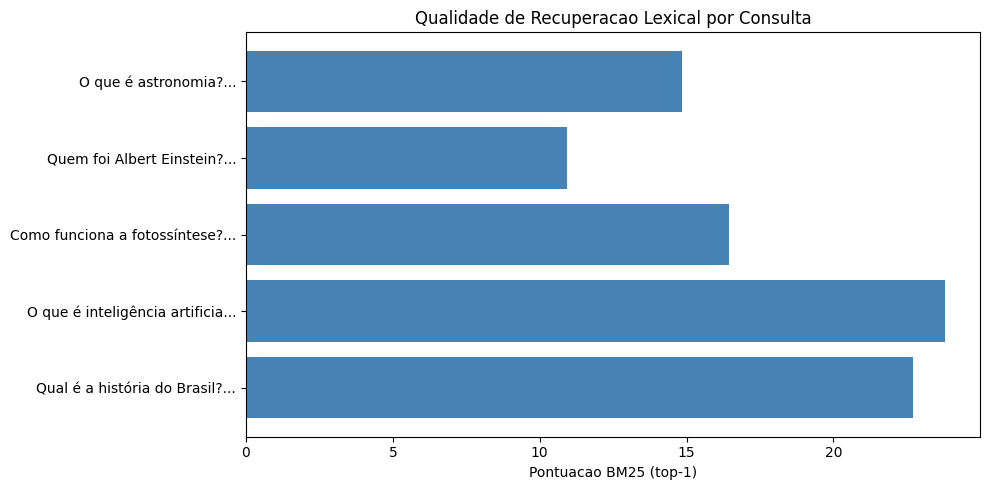

Grafico salvo.


In [11]:
import matplotlib.pyplot as plt

consultas_labels = [c[:30] + '...' for c in consultas_avaliacao]
pontuacoes_top1 = [resultados_avaliacao[c]['pontuacao_maxima'] for c in consultas_avaliacao]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(consultas_labels, pontuacoes_top1, color='steelblue')
ax.set_xlabel('Pontuacao BM25 (top-1)')
ax.set_title('Qualidade de Recuperacao Lexical por Consulta')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(caminho_processed / 'metricas_bm25.png', dpi=120)
plt.show()
print('Grafico salvo.')